In [1]:
# pgd-cifar10: normalize CWD to project root
import os
import pathlib

while (
    not pathlib.Path("pyproject.toml").exists() and pathlib.Path.cwd() != pathlib.Path.cwd().parent
):
    os.chdir("..")

In [2]:
!pytest tests/test_attacks/ -q

..........................                                               [100%]


# **THỰC NGHIỆM — DEMO TRỰC QUAN TẤN CÔNG ADVERSARIAL (WHITE-BOX, GRAY-BOX, BLACK-BOX)**

Notebook này **demo trực quan** ba ngữ cảnh tấn công của dự án `pgd-cifar10-experiment` trên dataset CIFAR-10. Khác với benchmark đầy đủ (10 000 mẫu test), ở đây attack được sinh **trực tiếp tại runtime trên 100 ảnh** (hiển thị theo grid `20 × 5` — 5 ảnh / hàng) để xem rõ:

1. **Giả định về mô hình Target/Victim** — Kiến trúc và trạng thái huấn luyện được xét.
2. **Ngữ cảnh tấn công** — Phân loại white-box / gray-box / black-box theo mức kiến thức của bên tấn công.
3. **Dữ liệu sử dụng** — 100 ảnh đầu của CIFAR-10 test set (thứ tự deterministic), miền pixel `[0, 1]`, chuẩn hoá channel-wise CIFAR-10 được gắn cố định bên trong model qua `Normalizer`. Cả bốn panel attack (white-box, gray-box, cross-arch, black-box) đều dùng đúng 100 ảnh này để có thể đếm trực tiếp số ảnh bị lừa.
4. **Thực nghiệm tấn công** — bốn panel grid `20 × 5` cho bốn threat model (white-box PGD-10; gray-box same-arch transfer; cross-arch transfer ResNet ↔ ViT; black-box Square 1000 queries) trên cả hai kiến trúc ResNet-18 và ViT-Tiny; mỗi ô là một ảnh adversarial kèm `y → pred_adv ✓/✗`; tiêu đề panel ghi clean accuracy và mini-ASR (số bị lừa / 100).
5. **Tổng kết** — bảng so sánh `fooled / 100` của bốn threat model trên cùng victim ResNet-18 để thấy khoảng cách white-box → gray-box / cross-arch / black-box, kèm panel visualization `10 × Δ` trên 5 ảnh đầu để phân biệt cấu trúc nhiễu của gradient-based attack (PGD: nhiễu tần số cao, rải khắp) vs query-based attack (Square: mảng vuông phẳng).

Notebook chỉ chạy attack thật trên 100 mẫu để vừa thấy hành vi của victim, vừa có một con số tổng hợp gọn nhẹ. Số liệu đầy đủ trên 10 000 mẫu xem ở [`results/logs/experiment.log`](../results/logs/experiment.log).

In [3]:
from dataclasses import replace

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from src.attacks.square import SquareAttack
from src.experiments.config_loader import load_attack_config
from src.reporting.attack import build_attack_for_report
from src.reporting.constants import ARCHES, SEED
from src.reporting.loaders import evaluation_inputs
from src.reporting.registry import build_fresh_model, reporting_model_pair
from src.utils.seed import set_all_seeds
from src.visualize.style import apply_style

apply_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

CIFAR10_CLASSES = [
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
DEMO_N = 100
PER_ROW = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_all_seeds(SEED)


def load_victim(arch: str, variant: str):
    """Load checkpoint cho (arch, variant); fallback random weights nếu thiếu."""
    pair = reporting_model_pair(arch, SEED)
    ckpt = pair.clean if variant == "clean" else pair.adversarial
    model = ckpt.load_or_none()
    if model is None:
        print(f"[!] {arch}/{variant} checkpoint thiếu — dùng random weights (smoke only)")
        model = build_fresh_model(arch)
    return model.to(DEVICE).eval()


def _make_grid(n, per_row, cell_w=1.7, cell_h=1.95):
    """Tạo grid (rows × per_row). cell_h > cell_w để chừa chỗ cho title của axis;
    constrained_layout đảm bảo title không đè lên ảnh, suptitle không cắt."""
    rows = (n + per_row - 1) // per_row
    fig, axes = plt.subplots(
        rows, per_row,
        figsize=(per_row * cell_w, rows * cell_h),
        constrained_layout=True,
    )
    if rows == 1:
        axes = axes.reshape(1, -1)
    return fig, axes


def show_attack_grid(victim, x, x_adv, y, title):
    """Show DEMO_N ảnh adversarial trên grid (DEMO_N / PER_ROW) × PER_ROW.

    Tiêu đề mỗi ô: `y → pred_adv ✓/✗`. Tiêu đề toàn panel: clean accuracy
    + số ảnh bị lừa / tổng (mini-ASR trên 100 mẫu).
    """
    x_adv_cpu = x_adv.detach().cpu()
    y_cpu = y.detach().cpu()
    with torch.no_grad():
        pred_clean = victim(x.to(DEVICE)).argmax(dim=1).cpu()
        pred_adv = victim(x_adv.to(DEVICE)).argmax(dim=1).cpu()
    n = x_adv_cpu.size(0)
    fig, axes = _make_grid(n, PER_ROW)
    flat = axes.flatten()
    for i in range(len(flat)):
        flat[i].axis("off")
        if i >= n:
            continue
        ok = pred_adv[i].item() == y_cpu[i].item()
        flat[i].imshow(x_adv_cpu[i].clamp(0, 1).permute(1, 2, 0).numpy())
        flat[i].set_title(
            f"{CIFAR10_CLASSES[y_cpu[i].item()]}→"
            f"{CIFAR10_CLASSES[pred_adv[i].item()]} "
            f"{'✓' if ok else '✗'}",
            fontsize=7,
            pad=2,
        )
    n_fooled = int((pred_adv != y_cpu).sum().item())
    n_clean_correct = int((pred_clean == y_cpu).sum().item())
    fig.suptitle(
        f"{title}\n"
        f"Clean correct: {n_clean_correct}/{n}  ·  "
        f"Bị lừa sau attack: {n_fooled}/{n} ({n_fooled / n * 100:.1f}%)",
        fontsize=12,
    )
    return fig


def fooled_count(victim, x_adv, y) -> int:
    with torch.no_grad():
        preds = victim(x_adv.to(DEVICE)).argmax(dim=1).cpu()
    return int((preds != y.detach().cpu()).sum().item())

## **1. Giả định về mô hình Target/Victim**

- **Kiến trúc**: hai họ mô hình tiêu biểu cho CNN và Transformer trên ảnh nhỏ — `resnet18` và `vit_tiny`. Cả hai được build qua `src.models.builders` và bọc bởi `Normalizer` để nhận trực tiếp ảnh raw `[0, 1]`; chuẩn hoá CIFAR-10 (mean/std) được gắn cố định vào model, do đó tấn công thực hiện trong miền pixel.
- **Trạng thái huấn luyện** (variant): mỗi kiến trúc có hai checkpoint với cùng `seed=42`:
  - `clean` — huấn luyện chuẩn (chỉ cross-entropy).
  - `adv` (`adversarial`) — adversarial training với inner attack APGD-CE-10, `epsilon=8/255`.
- **Số seed**: project sử dụng single-seed (`SEED=42`) cho toàn bộ phase thực nghiệm; các bảng `mean/std` (ví dụ bảng Square) bằng `std` rỗng khi `n_runs=1`.
- **Quy ước**: trong gray-box transfer, *surrogate* là mô hình tấn công tạo perturbation, *victim* là mô hình bị tấn công thực sự.

In [4]:
model_rows = []
for arch in ARCHES:
    pair = reporting_model_pair(arch, SEED)
    model_rows.append(
        {
            "architecture": arch,
            "seed": SEED,
            "clean_checkpoint": "available" if pair.clean.exists else "missing",
            "adv_checkpoint": "available" if pair.adversarial.exists else "missing",
            "clean_path": str(pair.clean.path),
            "adv_path": str(pair.adversarial.path),
        }
    )
display(pd.DataFrame(model_rows))

,architecture,seed,clean_checkpoint,adv_checkpoint,clean_path,adv_path
0,resnet18,42,available,available,checkpoints/clean/resnet18_seed42.pt,checkpoints/adv/resnet18_apgd_at_seed42.pt
1,vit_tiny,42,available,available,checkpoints/clean/vit_tiny_seed42.pt,checkpoints/adv/vit_tiny_apgd_at_seed42.pt


## **2. Ngữ cảnh tấn công**

Mỗi ngữ cảnh khác nhau ở **mức kiến thức** bên tấn công có về mô hình target và **cách truy cập** (gradient hay chỉ truy vấn).

| Ngữ cảnh | Kiến thức về target | Có gradient? | Có truy cập trọng số? | Attack dùng trong demo |
|---|---|---|---|---|
| **White-box** | Đầy đủ (kiến trúc + trọng số) | Có | Có | PGD-10 trên victim `clean` |
| **Gray-box** | Cùng kiến trúc, khác variant (`clean` vs `adv`) | Có (trên surrogate) | Trên surrogate | PGD-10 surrogate `clean` → victim `adv` |
| **Cross-arch** | Cùng variant `clean` nhưng **khác kiến trúc** (CNN ↔ Transformer) | Có (trên surrogate) | Trên surrogate | PGD-10 ResNet-18 ↔ ViT-Tiny |
| **Black-box** | Chỉ truy vấn `f(x)` (logits/label); không gradient | Không | Không | Square Attack 1000 queries |

White-box thường được dùng để **đặt cận trên cho mức độ thành công** của một họ tấn công gradient-based. Gray-box (same-arch), cross-arch, và black-box là các threat model thực tế hơn — kết quả ở những ngữ cảnh này phản ánh độ vững chắc của mô hình trong điều kiện thực tế.

In [16]:
threat_models = pd.DataFrame(
    [
        {
            "context": "white-box",
            "attacker_knowledge": "Architecture + weights (full access)",
            "uses_gradient": True,
            "query_budget": "unlimited",
            "attacks_in_demo": "PGD-10 vs victim clean",
        },
        {
            "context": "gray-box (same-arch)",
            "attacker_knowledge": "Same arch, different variant (clean surrogate -> adv victim)",
            "uses_gradient": True,
            "query_budget": "unlimited (on surrogate)",
            "attacks_in_demo": "PGD-10 surrogate(clean) -> victim(adv)",
        },
        {
            "context": "cross-arch",
            "attacker_knowledge": "Different architecture (CNN <-> Transformer), same clean variant",
            "uses_gradient": True,
            "query_budget": "unlimited (on surrogate)",
            "attacks_in_demo": "PGD-10 ResNet-18 <-> ViT-Tiny",
        },
        {
            "context": "black-box",
            "attacker_knowledge": "Query access only (logits, no gradients)",
            "uses_gradient": False,
            "query_budget": "1000 queries",
            "attacks_in_demo": "Square Attack (Linf, p_init=0.05)",
        },
    ]
)
display(threat_models)

,context,attacker_knowledge,uses_gradient,query_budget,attacks_in_demo
0,white-box,Architecture + weights (full access),True,unlimited,PGD-10 vs victim clean
1,gray-box (same-arch),"Same arch, different variant (clean surrogate ...",True,unlimited (on surrogate),PGD-10 surrogate(clean) -> victim(adv)
2,cross-arch,"Different architecture (CNN <-> Transformer), ...",True,unlimited (on surrogate),PGD-10 ResNet-18 <-> ViT-Tiny
3,black-box,"Query access only (logits, no gradients)",False,1000 queries,"Square Attack (Linf, p_init=0.05)"


## **3. Dữ liệu sử dụng**

- **Dataset**: CIFAR-10, 10 lớp, 50 000 ảnh train / 10 000 ảnh test, mỗi ảnh 32×32 RGB.
- **Miền pixel**: ảnh được giữ ở `[0, 1]`; chuẩn hoá channel-wise (mean/std CIFAR-10) được thực hiện *bên trong* model thông qua `Normalizer`. Nhờ vậy ràng buộc `Linf(epsilon)` cũng áp dụng trên miền pixel `[0, 1]`, tương đương `epsilon = 8/255 ≈ 0.0314`.
- **Set cho demo trực quan**: `evaluation_inputs(100)` trả về **100 ảnh đầu** của CIFAR-10 test split (thứ tự deterministic, không phụ thuộc seed); `SEED=42` chỉ kiểm soát RNG của PGD/Square (random start, vị trí miếng vuông). Hiển thị theo grid `20 × 5` (5 ảnh / hàng). Cả ba phần demo (white-box / gray-box / black-box) đều dùng đúng 100 ảnh này — đếm được trực tiếp số ảnh bị lừa.

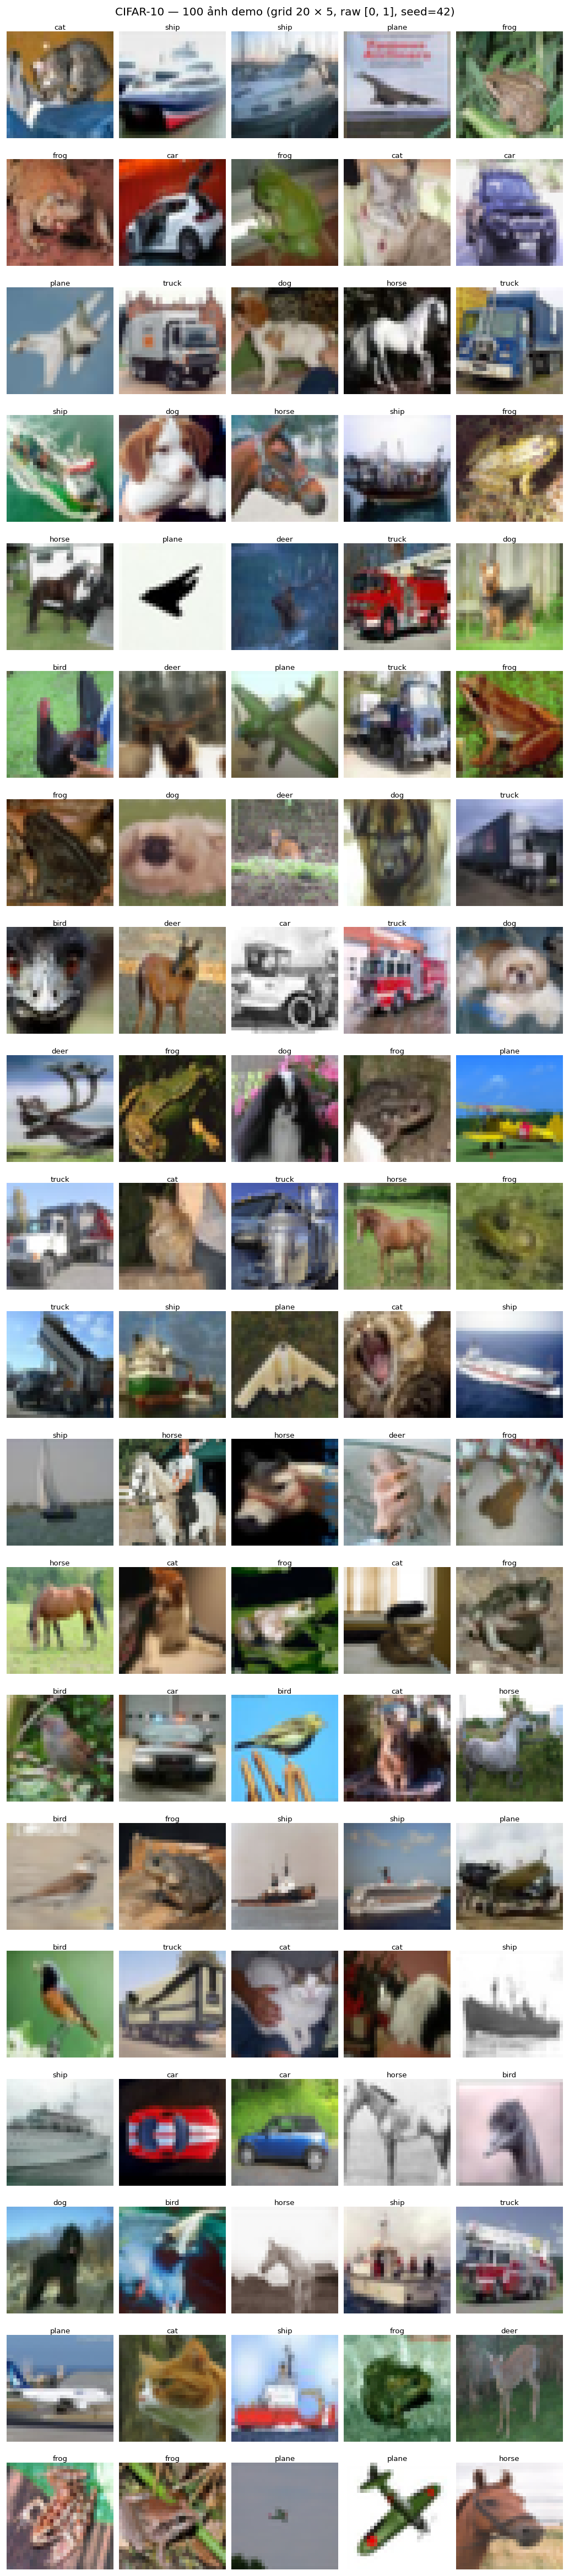

In [6]:
x_demo, y_demo = evaluation_inputs(DEMO_N)
x_demo = x_demo.to(DEVICE)
y_demo = y_demo.to(DEVICE)

fig, axes = _make_grid(DEMO_N, PER_ROW)
flat = axes.flatten()
for i in range(len(flat)):
    flat[i].axis("off")
    if i >= DEMO_N:
        continue
    flat[i].imshow(x_demo[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    flat[i].set_title(CIFAR10_CLASSES[int(y_demo[i].item())], fontsize=8, pad=2)
fig.suptitle(
    f"CIFAR-10 — {DEMO_N} ảnh demo (grid {DEMO_N // PER_ROW} × {PER_ROW}, raw [0, 1], seed={SEED})",
    fontsize=12,
)
plt.show()

## **4. Thực nghiệm tấn công**

Mỗi attack được hiển thị bằng một **grid `20 × 5`** (5 ảnh / hàng, 100 ảnh adversarial):

- Mỗi ô là **ảnh adversarial** (đã bị attack, vẫn trong ràng buộc `Linf ≤ 8/255`).
- Tiêu đề ô: `y → pred_adv` kèm `✓` (victim vẫn đoán đúng — attack thất bại) hoặc `✗` (victim đoán sai — attack thành công).
- Tiêu đề toàn panel ghi **clean accuracy** (số ảnh victim đoán đúng *trước* attack) và **số bị lừa / tổng** (mini-ASR trên 100 ảnh).

So sánh trực quan: panel nào **nhiều `✗` hơn** → attack hiệu quả hơn / victim yếu hơn. Cấu trúc cụ thể của perturbation (nhiễu tần số cao vs mảng vuông) được xem ở section 4.5 trên một subset nhỏ.

## 4.1. Demo white-box — PGD-10 trên victim `clean`

White-box = kẻ tấn công biết kiến trúc + trọng số → có gradient. PGD-10 đẩy ảnh đi 10 bước theo dấu gradient (`alpha = 2/255`) và project lại về `Linf-ball(epsilon = 8/255)` sau mỗi bước. Victim là model `clean` (chỉ huấn luyện cross-entropy), được kỳ vọng dễ bị đánh thủng.

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/autograd/graph.py:829: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


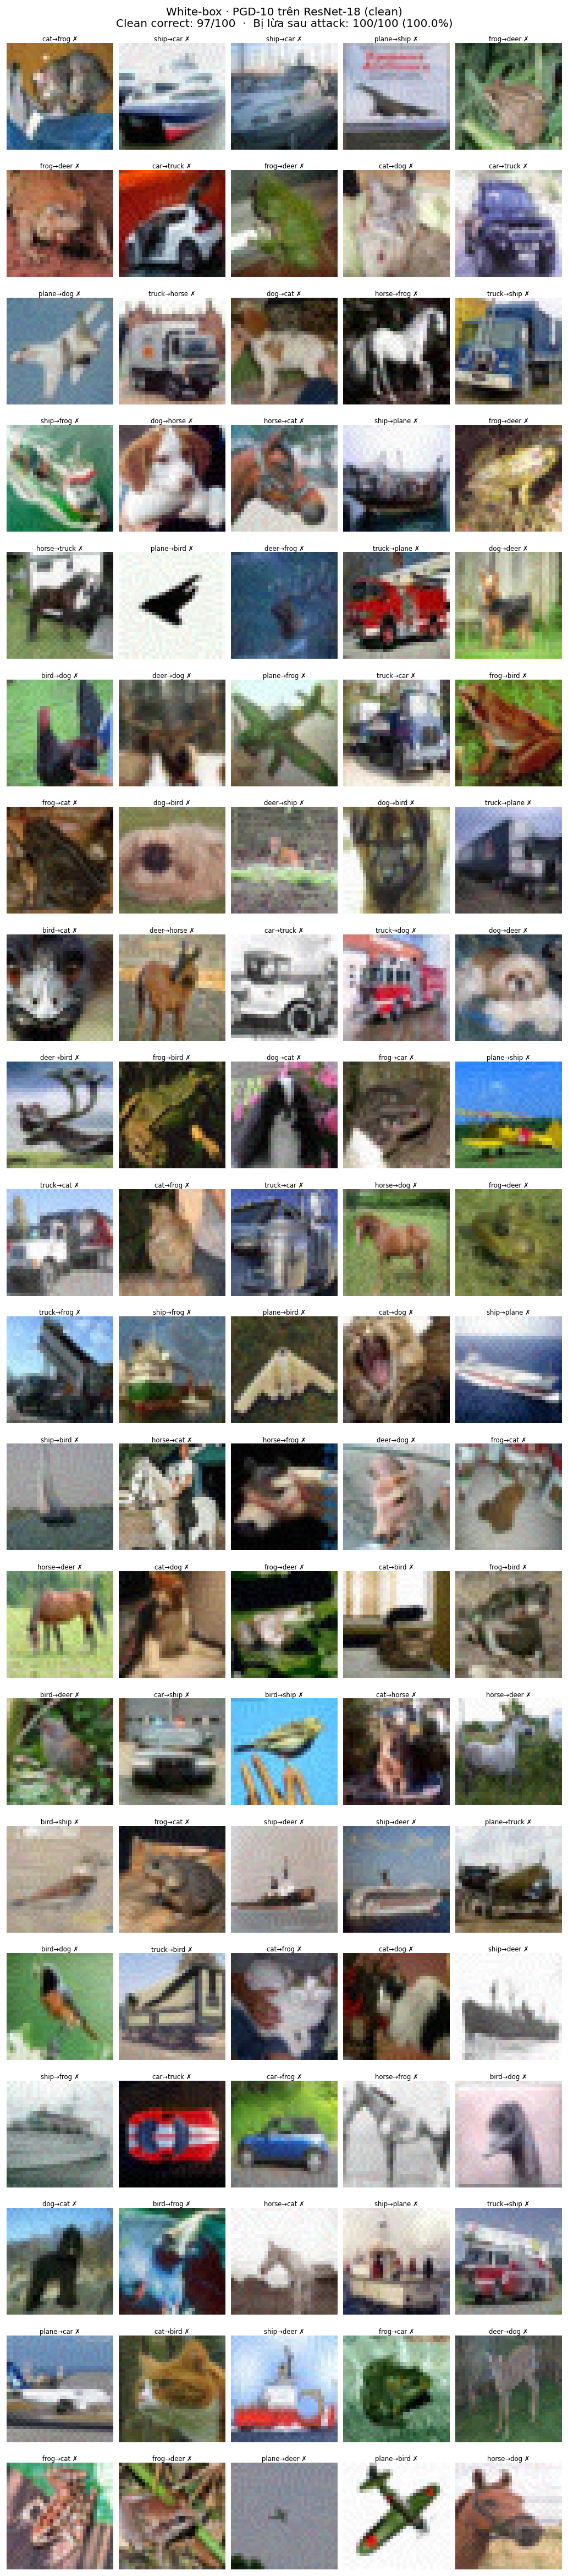

In [7]:
pgd10 = build_attack_for_report("pgd_10")

victim_r18_clean = load_victim("resnet18", "clean")
x_adv_wb_r18 = pgd10.perturb(victim_r18_clean, x_demo, y_demo)
show_attack_grid(
    victim_r18_clean, x_demo, x_adv_wb_r18, y_demo,
    title="White-box · PGD-10 trên ResNet-18 (clean)",
)
plt.show()

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/functional.py:5695: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  proj = linear(q, w, b)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/autograd/graph.py:829: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (T

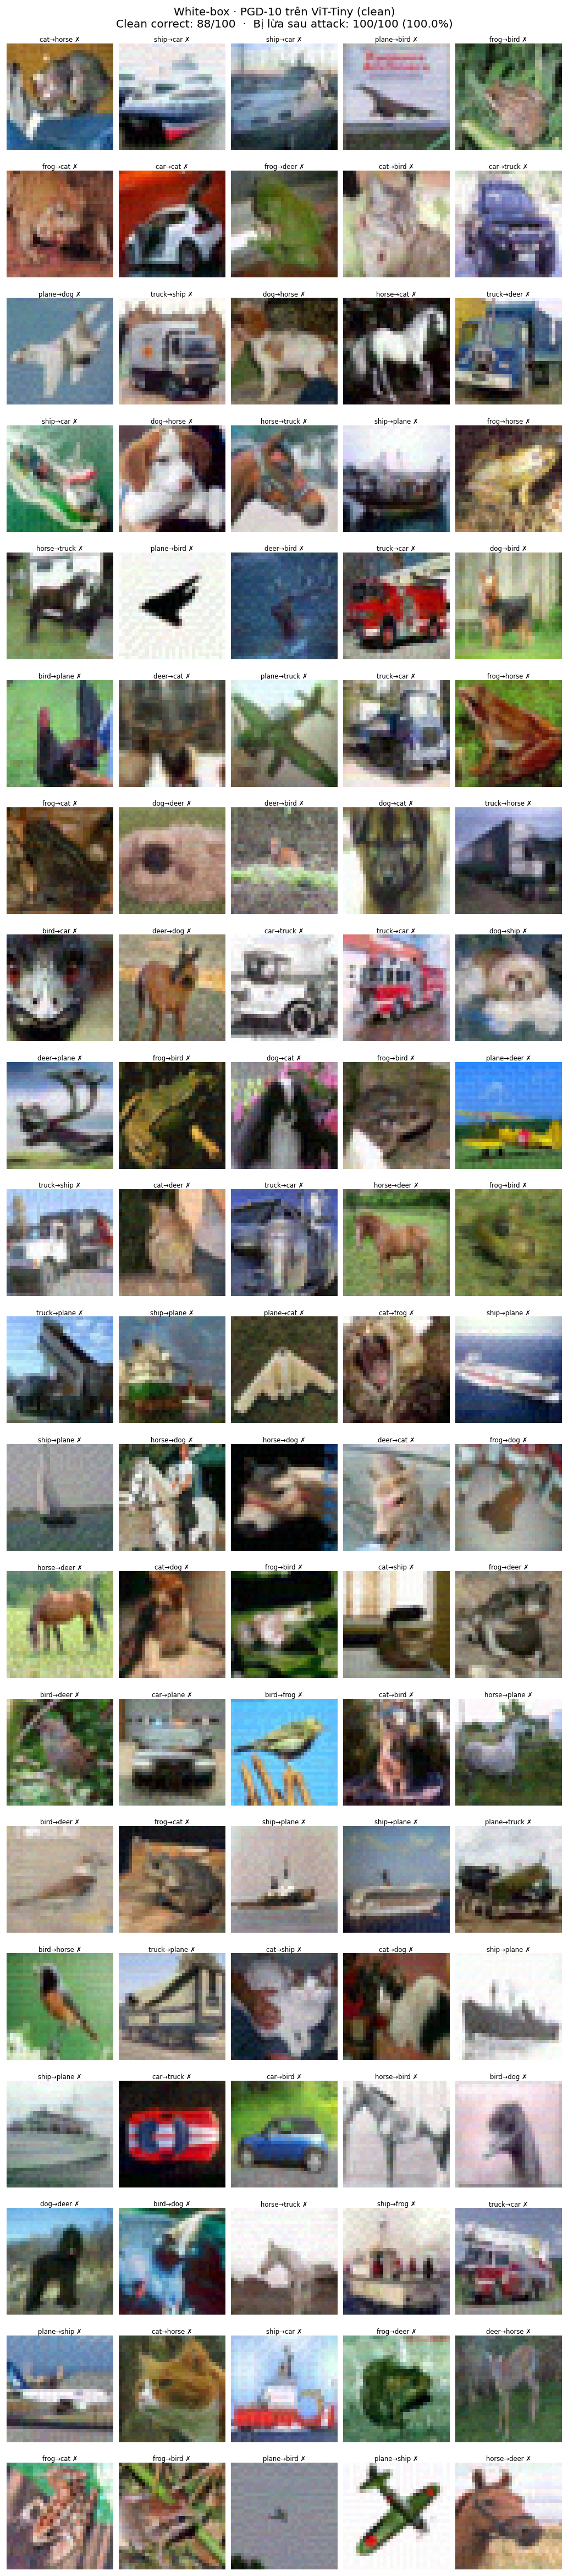

In [8]:
victim_vit_clean = load_victim("vit_tiny", "clean")
x_adv_wb_vit = pgd10.perturb(victim_vit_clean, x_demo, y_demo)
show_attack_grid(
    victim_vit_clean, x_demo, x_adv_wb_vit, y_demo,
    title="White-box · PGD-10 trên ViT-Tiny (clean)",
)
plt.show()

**Đọc panel white-box:**

- Tỉ lệ ô `✗` (bị lừa) trên 100 ảnh thường rất cao — PGD-10 với `epsilon = 8/255` đánh thủng gần hết victim `clean`, khớp với `ASR ≈ 1.0` trên 10 000 mẫu benchmark.
- Dự đoán mới sau attack rơi vào **lớp có gradient loss lớn nhất tại điểm clean** — không nhất thiết là lớp ngữ nghĩa gần (ví dụ `ship → plane`), mà là lớp mà PGD có thể đẩy logit vượt qua nhanh nhất trong `Linf-ball(8/255)`.
- Vài ô vẫn `✓` thường là những ảnh có margin clean rất lớn — PGD-10 chỉ 10 bước có thể chưa đủ để vượt biên. Tăng `num_steps` (PGD-100) sẽ "dọn sạch" thêm.
- So sánh ResNet-18 vs ViT-Tiny: tỉ lệ "bị lừa" thường tương đương — cả hai kiến trúc clean đều không có robustness có ý nghĩa.

## 4.2. Demo gray-box — PGD-10 sinh từ surrogate `clean`, áp vào victim `adv`

Gray-box (same-arch): kẻ tấn công **biết kiến trúc** của victim nhưng **không có trọng số**; thay vào đó dùng một model cùng kiến trúc đã huấn luyện riêng (surrogate) để xấp xỉ gradient. Đây là threat model "có thông tin về kiến trúc, không có trọng số victim". Pipeline:

1. Sinh perturbation `x_adv` bằng PGD-10 **trên surrogate** (ResNet-18 hoặc ViT-Tiny ở variant `clean`).
2. Đem `x_adv` qua **victim** thật — cùng kiến trúc nhưng ở variant `adv` (đã adversarial training).

Nếu adversarial training thực sự khác clean model về decision boundary, perturbation transfer sẽ ít hiệu quả hơn so với white-box.

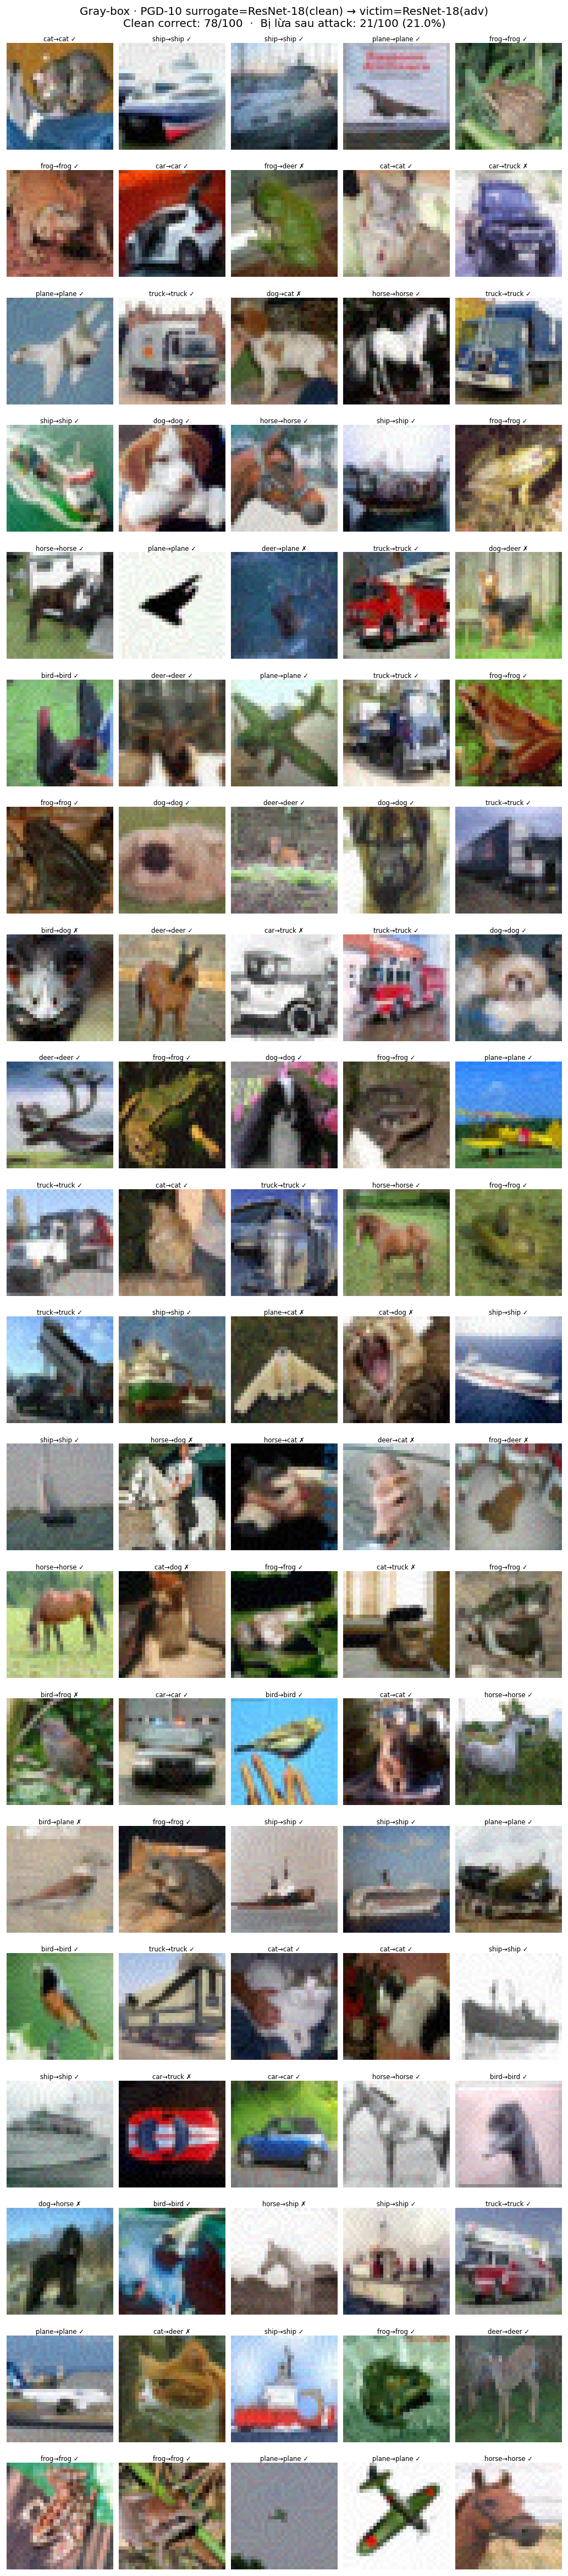

In [9]:
victim_r18_adv = load_victim("resnet18", "adv")
x_adv_gb_r18 = pgd10.perturb(victim_r18_clean, x_demo, y_demo)  # sinh trên surrogate (clean)
show_attack_grid(
    victim_r18_adv, x_demo, x_adv_gb_r18, y_demo,
    title="Gray-box · PGD-10 surrogate=ResNet-18(clean) → victim=ResNet-18(adv)",
)
plt.show()

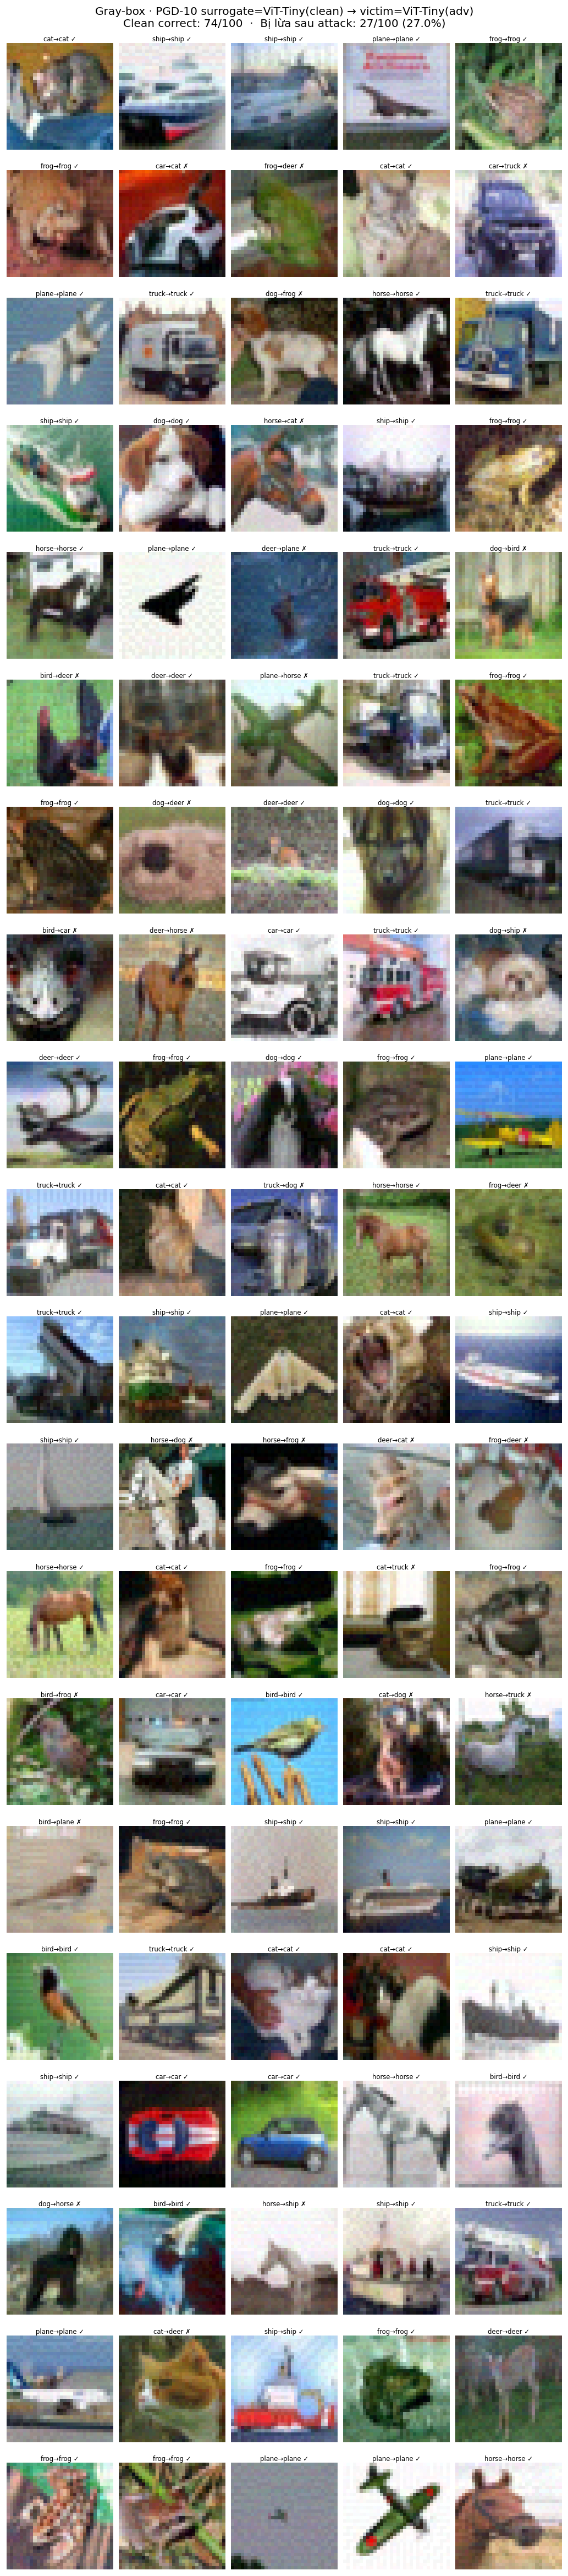

In [10]:
victim_vit_adv = load_victim("vit_tiny", "adv")
x_adv_gb_vit = pgd10.perturb(victim_vit_clean, x_demo, y_demo)  # sinh trên surrogate (clean)
show_attack_grid(
    victim_vit_adv, x_demo, x_adv_gb_vit, y_demo,
    title="Gray-box · PGD-10 surrogate=ViT-Tiny(clean) → victim=ViT-Tiny(adv)",
)
plt.show()

**Đọc panel gray-box:**

- So với white-box ở 4.1, số ô `✗` trên 100 ảnh **giảm rõ rệt**: victim `adv` (đã adversarial training) chống lại được phần lớn perturbation sinh từ surrogate `clean`. Decision boundary của hai model khác đủ để gradient không trỏ đúng hướng cho victim — adversarial training làm boundary của victim **phẳng hơn quanh điểm sạch** (true robustness, không phải gradient masking).
- Khoảng cách giữa "số bị lừa" ở panel 4.1 (white-box) và 4.2 (gray-box) chính là **giá trị bảo vệ** mà adversarial training mang lại trong threat model gray-box thực tế.
- Perturbation `x_adv` *được sinh* đầy budget `Linf = 8/255` (vì PGD-10 chạy trên surrogate đầy đủ); chỉ có **hướng** của nó không tối ưu cho victim mới.

## 4.3. Demo cross-arch transfer (CNN ↔ Transformer)

Cross-arch transfer là threat model riêng trong project (mode `cross_arch` ở [`scripts/run_transfer.py`](../scripts/run_transfer.py), config [`configs/transfer/transfer_pairs.yaml`](../configs/transfer/transfer_pairs.yaml)): surrogate và victim **cùng variant `clean`** nhưng **khác kiến trúc** (CNN ↔ Transformer). Câu hỏi: gradient sinh trên một họ network có "vượt rào" sang họ khác không?

Tận dụng perturbation đã sinh ở section 4.1 (không cần chạy PGD lại):
- `x_adv_wb_r18` (sinh trên ResNet-18) ⇒ áp lên victim ViT-Tiny(clean).
- `x_adv_wb_vit` (sinh trên ViT-Tiny) ⇒ áp lên victim ResNet-18(clean).

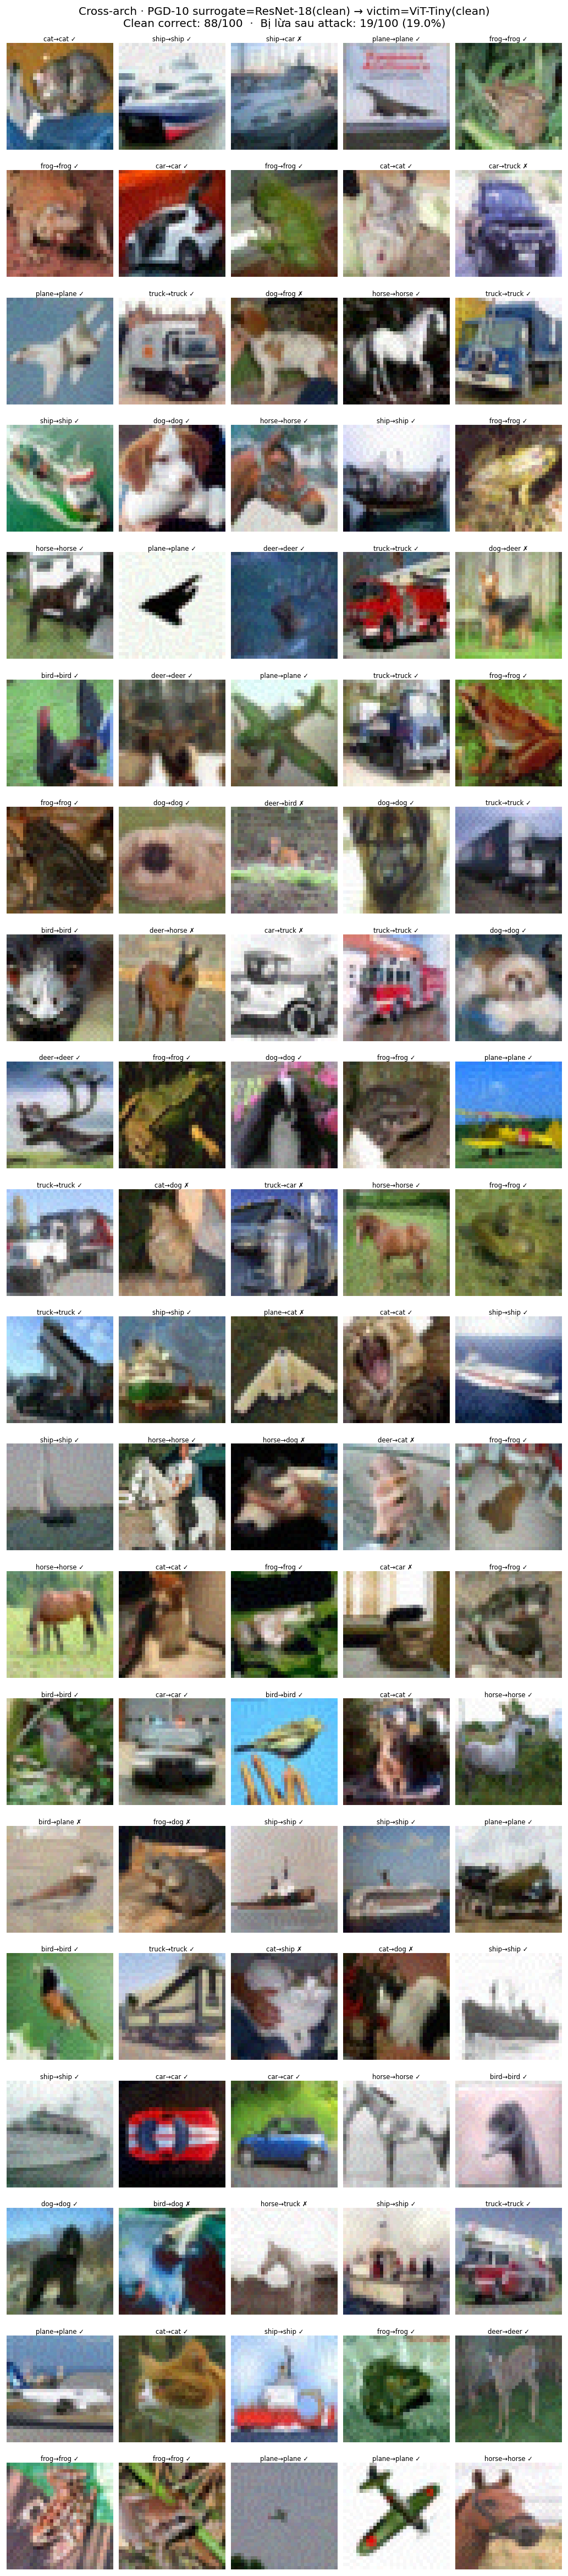

In [11]:
# Cross-arch: perturbation sinh trên ResNet-18(clean), áp lên ViT-Tiny(clean)
# Tận dụng x_adv_wb_r18 đã sinh ở section 3.5 — không cần chạy PGD lại.
show_attack_grid(
    victim_vit_clean, x_demo, x_adv_wb_r18, y_demo,
    title="Cross-arch · PGD-10 surrogate=ResNet-18(clean) → victim=ViT-Tiny(clean)",
)
plt.show()

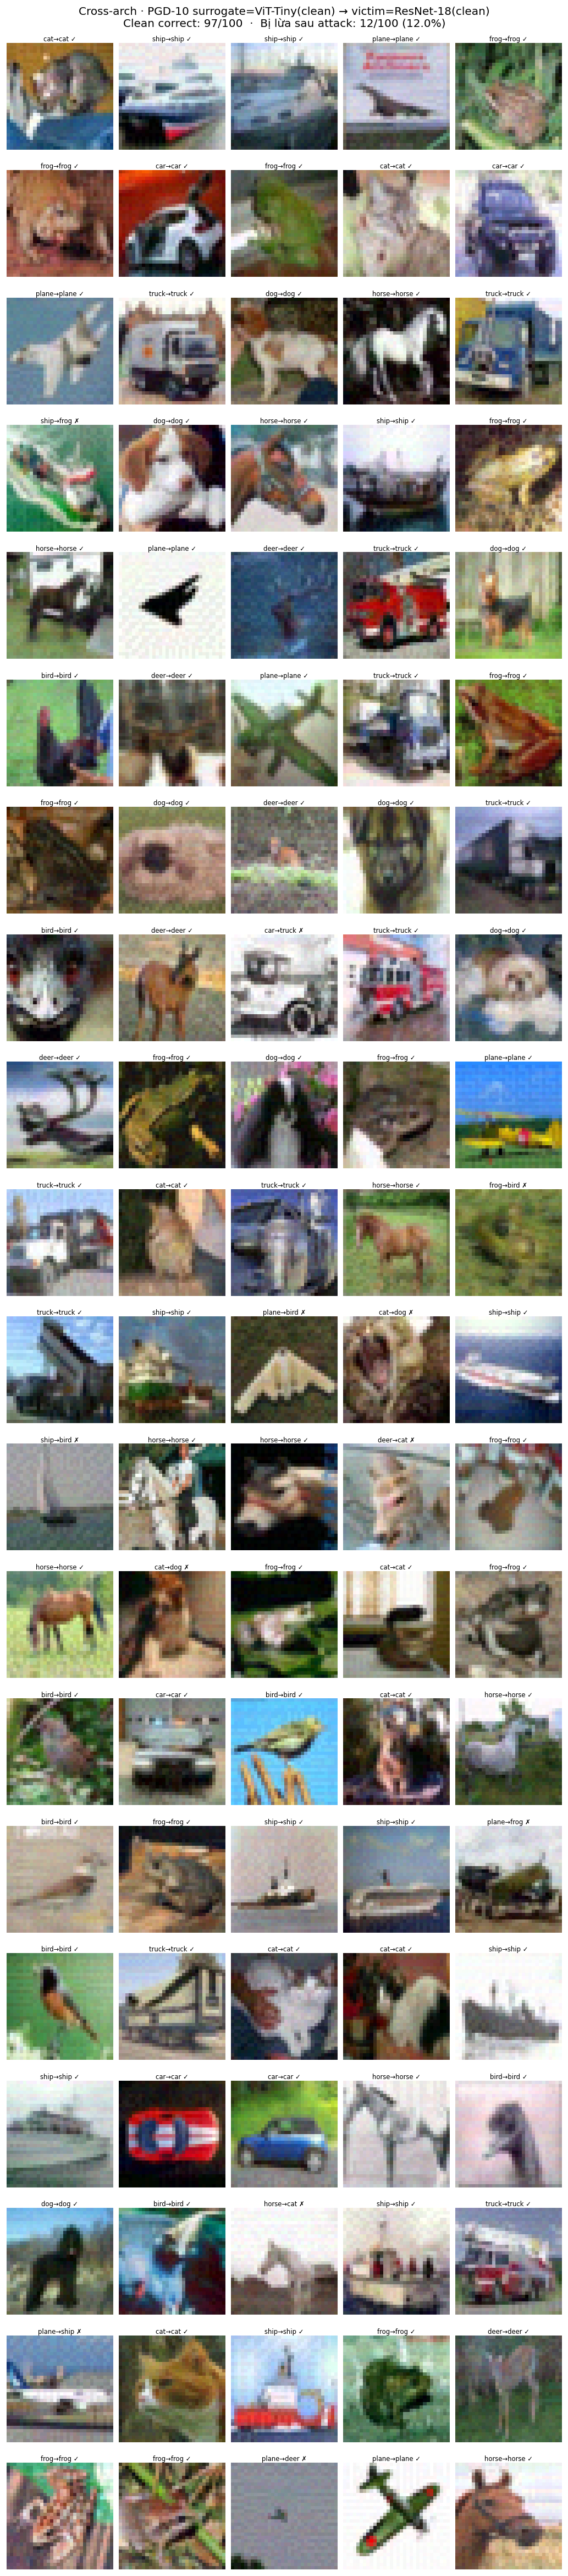

In [12]:
# Chiều ngược lại: perturbation sinh trên ViT-Tiny(clean), áp lên ResNet-18(clean)
show_attack_grid(
    victim_r18_clean, x_demo, x_adv_wb_vit, y_demo,
    title="Cross-arch · PGD-10 surrogate=ViT-Tiny(clean) → victim=ResNet-18(clean)",
)
plt.show()

**Đọc panel cross-arch transfer:**

- So với white-box ở 4.1, số ô `✗` **giảm** rõ rệt: perturbation sinh từ surrogate khác kiến trúc không khớp với gradient của victim. Khoảng cách giữa "white-box" và "cross-arch" chính là *transferability gap* giữa CNN và Transformer.
- Hai chiều `ResNet → ViT` và `ViT → ResNet` thường **không đối xứng**. CNN có inductive bias locality (conv), Transformer có inductive bias toàn cục (attention) → gradient hướng tới điểm yếu của bên này có thể không phải điểm yếu của bên kia. Cụ thể hơn, transferability phụ thuộc vào việc gradient PGD có chiếu xuống *shared adversarial subspace* hay không — khác kiến trúc thường có shared subspace nhỏ hơn khác variant.
- So với gray-box same-arch ở 4.2 (`clean → adv`): cross-arch thường có **nhiều `✗` hơn** vì victim ở 4.3 vẫn là model `clean` (chưa adv-trained), trong khi 4.2 victim đã có defense. Khác kiến trúc < khác variant về mức bảo vệ.
- `Linf` thực tế vẫn ≈ `8/255` — perturbation đầy budget; chỉ hướng gradient không tối ưu cho kiến trúc victim.

## 4.4. Demo black-box — Square Attack (query-only, 1000 queries)

Black-box: kẻ tấn công không có gradient, chỉ truy vấn được `f(x)` (logits). Square Attack dán liên tiếp các **miếng vuông `±epsilon`** ở vị trí ngẫu nhiên trên ảnh; chỉ giữ miếng nào làm **margin loss** (logit của lớp đúng trừ max logit của các lớp còn lại) giảm — đây là greedy random search untargeted trong `Linf-ball(epsilon)`.

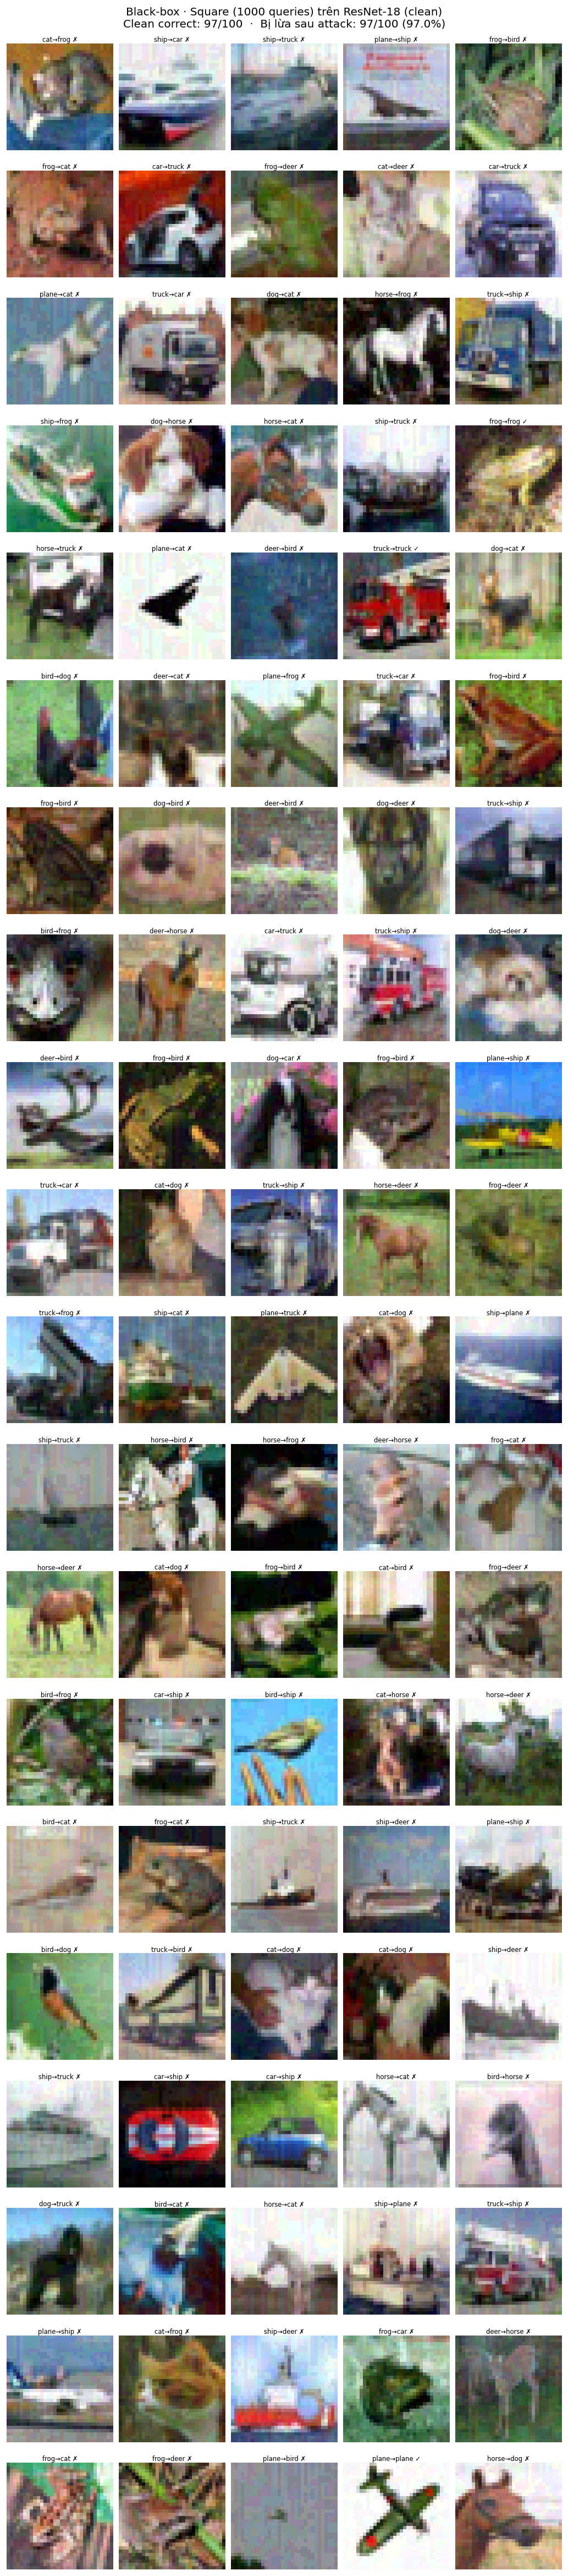

In [13]:
DEMO_QUERIES = 1000
square_cfg = replace(load_attack_config("square_5000"), num_steps=DEMO_QUERIES, seed=SEED)
square = SquareAttack(square_cfg)

x_adv_bb_r18 = square.perturb(victim_r18_clean, x_demo, y_demo)
show_attack_grid(
    victim_r18_clean, x_demo, x_adv_bb_r18, y_demo,
    title=f"Black-box · Square ({DEMO_QUERIES} queries) trên ResNet-18 (clean)",
)
plt.show()

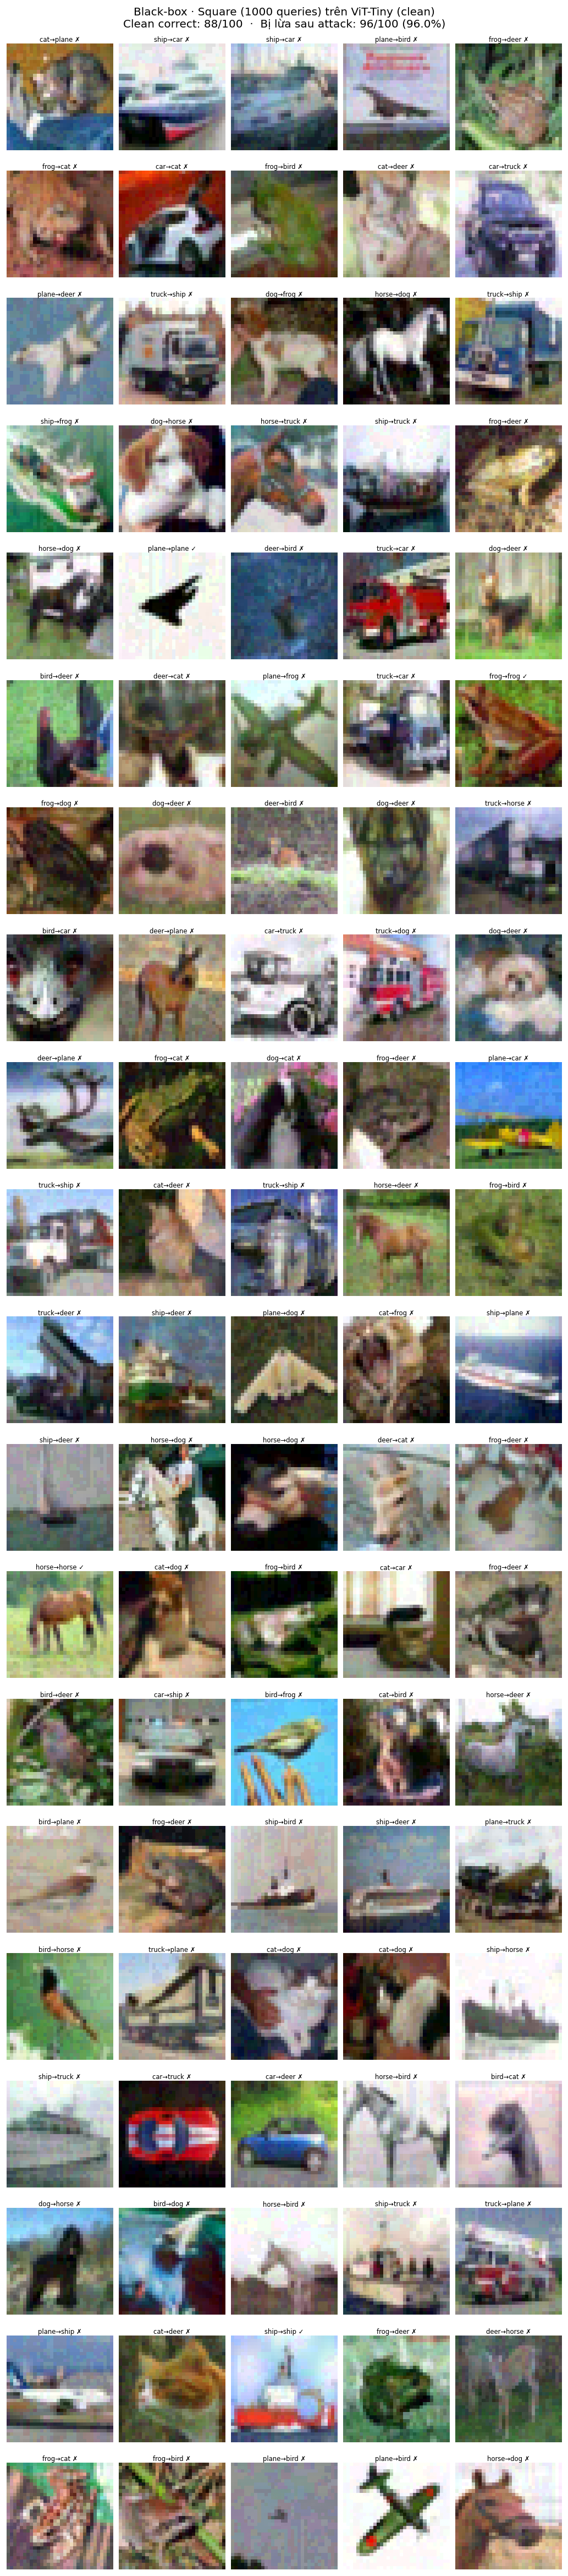

In [14]:
x_adv_bb_vit = square.perturb(victim_vit_clean, x_demo, y_demo)
show_attack_grid(
    victim_vit_clean, x_demo, x_adv_bb_vit, y_demo,
    title=f"Black-box · Square ({DEMO_QUERIES} queries) trên ViT-Tiny (clean)",
)
plt.show()

**Đọc panel black-box:**

- Trên 100 ảnh, Square 1000 queries thường lừa được **một phần đáng kể** victim `clean` — không cao bằng white-box vì không có gradient, nhưng vẫn nhiều hơn 0. Tăng lên 5000 queries sẽ thêm số bị lừa.
- Nếu nhìn kỹ ảnh adversarial sẽ thấy các **mảng vuông màu phẳng** lấp lánh — dấu vết của những miếng vá `±epsilon` mà Square dán lên ở vị trí ngẫu nhiên. Cấu trúc này sẽ rất rõ ở section 4.5 (visualization `10× Δ`).
- ResNet-18 và ViT-Tiny phản ứng khác nhau với Square: trong demo này, ViT-Tiny thường có `fooled / 100` thấp hơn ResNet-18 ở cùng 1000 queries — nhưng đây là quan sát trên 100 mẫu, không đại diện; xem kết quả benchmark cho ASR đầy đủ trên 10 000 mẫu.
- Demo dùng victim `clean`; trên victim `adv`, ASR của Square cũng giảm.

## 4.5. So sánh 3 threat model trên cùng 100 ảnh

Hai phần:

1. **Tổng hợp định lượng trên 100 ảnh** — bảng `fooled / 100` cho từng threat model trên victim ResNet-18, dễ so sánh khoảng cách white-box vs gray-box vs cross-arch vs black-box.
2. **Cấu trúc perturbation** — panel `10× Δ` trên **5 ảnh đầu** (1 hàng × 5 cột cho mỗi attack) để nhìn ra cấu trúc nhiễu khác biệt: gradient (PGD/cross-arch) để lại nhiễu tần số cao, Square để lại mảng vuông phẳng. Không show cả 100 vì panel sẽ quá cao và không thêm thông tin.

,threat_model,attack,surrogate,victim,fooled / 100
0,white-box,PGD-10,ResNet-18(clean),ResNet-18(clean),100
1,gray-box (same-arch),PGD-10 transfer,ResNet-18(clean),ResNet-18(adv),21
2,cross-arch,PGD-10 transfer,ViT-Tiny(clean),ResNet-18(clean),12
3,black-box,Square 1000q,—,ResNet-18(clean),97


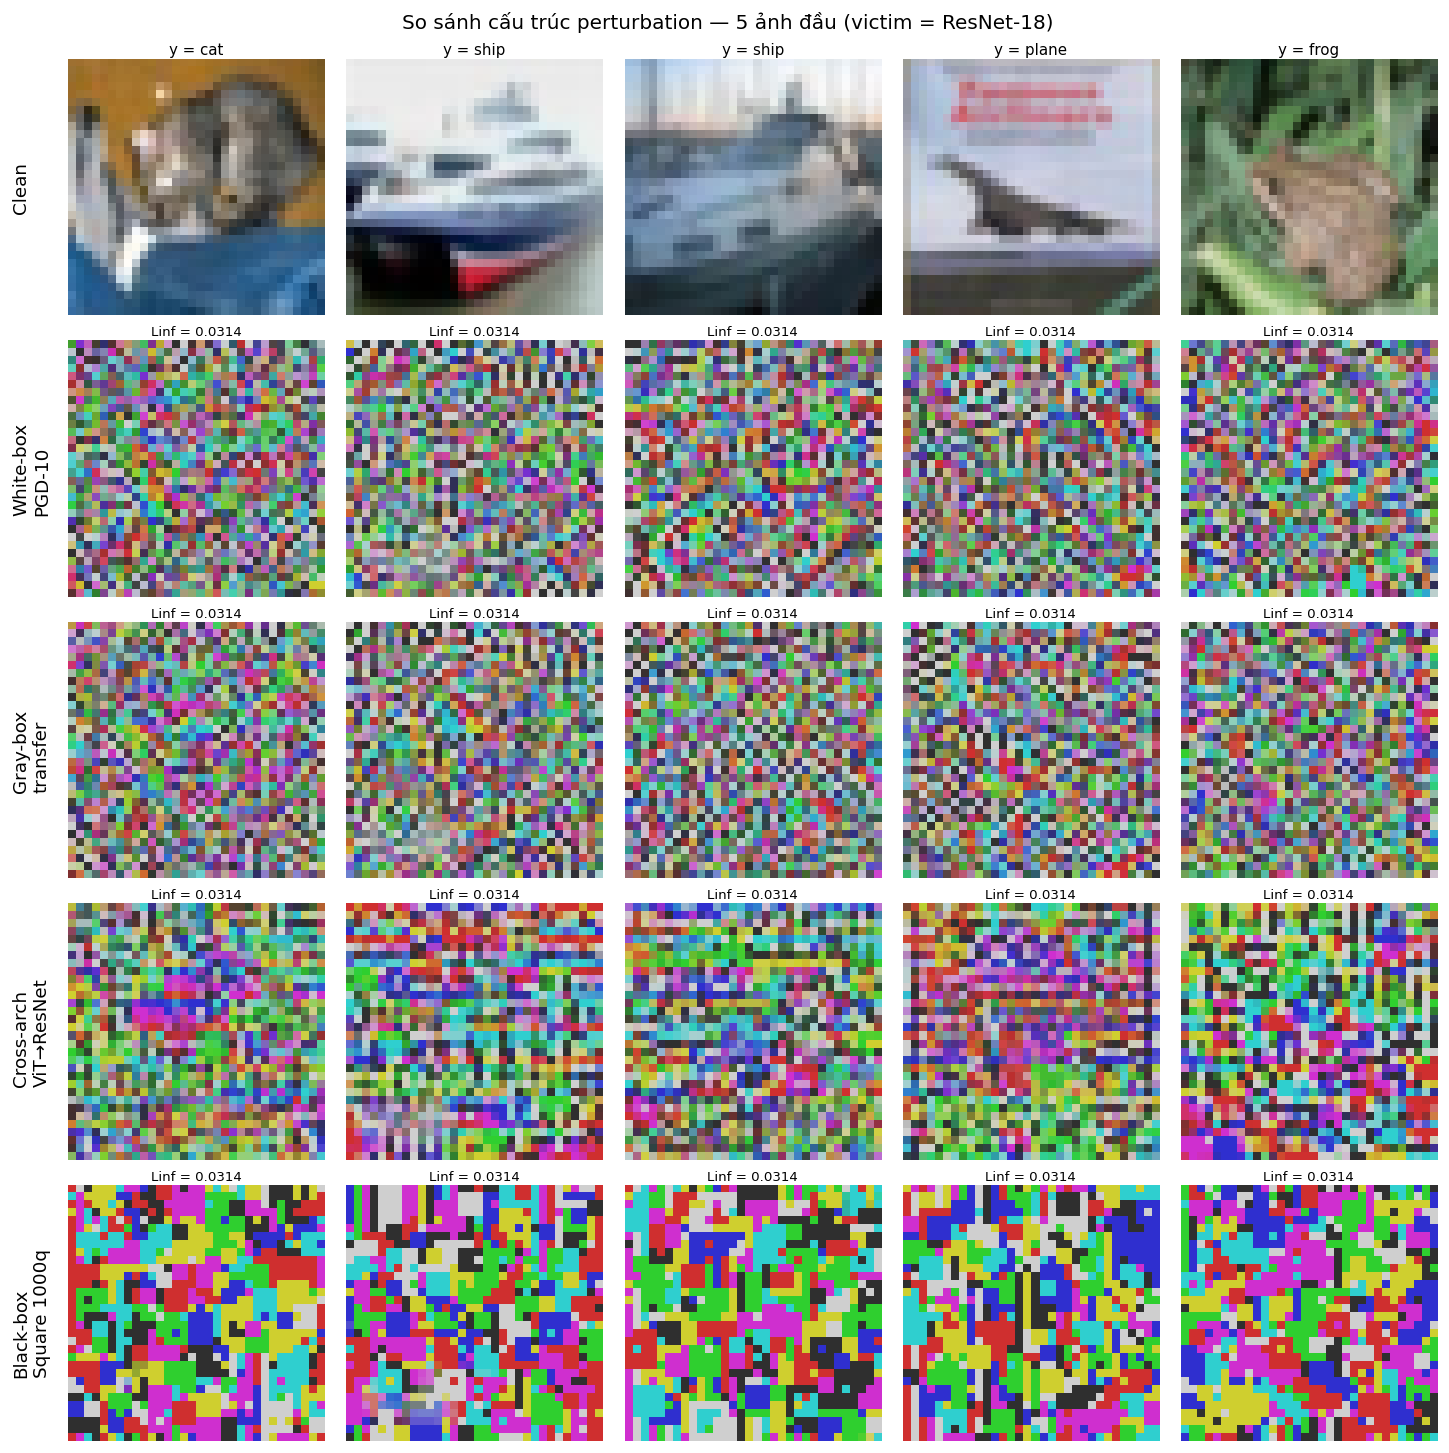

In [15]:
summary = pd.DataFrame(
    [
        {
            "threat_model": "white-box",
            "attack": "PGD-10",
            "surrogate": "ResNet-18(clean)",
            "victim": "ResNet-18(clean)",
            f"fooled / {DEMO_N}": fooled_count(victim_r18_clean, x_adv_wb_r18, y_demo),
        },
        {
            "threat_model": "gray-box (same-arch)",
            "attack": "PGD-10 transfer",
            "surrogate": "ResNet-18(clean)",
            "victim": "ResNet-18(adv)",
            f"fooled / {DEMO_N}": fooled_count(victim_r18_adv, x_adv_gb_r18, y_demo),
        },
        {
            "threat_model": "cross-arch",
            "attack": "PGD-10 transfer",
            "surrogate": "ViT-Tiny(clean)",
            "victim": "ResNet-18(clean)",
            f"fooled / {DEMO_N}": fooled_count(victim_r18_clean, x_adv_wb_vit, y_demo),
        },
        {
            "threat_model": "black-box",
            "attack": f"Square {DEMO_QUERIES}q",
            "surrogate": "—",
            "victim": "ResNet-18(clean)",
            f"fooled / {DEMO_N}": fooled_count(victim_r18_clean, x_adv_bb_r18, y_demo),
        },
    ]
)
display(summary)


N_VIS = PER_ROW  # số ảnh đầu để show cấu trúc perturbation
x_vis = x_demo[:N_VIS]
y_vis = y_demo[:N_VIS]
perturbations = {
    "White-box\nPGD-10": x_adv_wb_r18[:N_VIS],
    "Gray-box\ntransfer": x_adv_gb_r18[:N_VIS],
    "Cross-arch\nViT→ResNet": x_adv_wb_vit[:N_VIS],
    "Black-box\nSquare 1000q": x_adv_bb_r18[:N_VIS],
}

rows = 1 + len(perturbations)
fig, axes = plt.subplots(
    rows, N_VIS,
    figsize=(2.4 * N_VIS, 2.4 * rows),
    constrained_layout=True,
)
x_cpu = x_vis.detach().cpu()
y_cpu = y_vis.detach().cpu()
for i in range(N_VIS):
    axes[0, i].imshow(x_cpu[i].permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, i].set_title(f"y = {CIFAR10_CLASSES[int(y_cpu[i].item())]}", fontsize=9, pad=3)
    axes[0, i].axis("off")
axes[0, 0].text(-0.22, 0.5, "Clean", rotation=90, fontsize=11, va="center",
                transform=axes[0, 0].transAxes)
for row_idx, (name, x_adv_subset) in enumerate(perturbations.items(), start=1):
    delta = x_adv_subset.detach().cpu() - x_cpu
    for i in range(N_VIS):
        axes[row_idx, i].imshow((delta[i] * 10 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy())
        axes[row_idx, i].set_title(
            f"Linf = {delta[i].abs().max().item():.4f}", fontsize=8, pad=3,
        )
        axes[row_idx, i].axis("off")
    axes[row_idx, 0].text(-0.22, 0.5, name, rotation=90, fontsize=11, va="center",
                          transform=axes[row_idx, 0].transAxes)
fig.suptitle(
    f"So sánh cấu trúc perturbation — {N_VIS} ảnh đầu (victim = ResNet-18)",
    fontsize=12,
)
plt.show()

## **5. Tổng kết**

Demo trực quan trên 100 ảnh (grid `20 × 5`) đã cho thấy:

1. **White-box mạnh nhất**: PGD-10 trên victim `clean` lừa được phần lớn 100 mẫu (`fooled / 100` thường gần 100/100), khớp với `ASR ≈ 1.0` trên 10 000 mẫu ở benchmark.
2. **Adversarial training chống transfer rõ rệt**: panel gray-box same-arch (4.2) victim `adv` giữ được dự đoán đúng ở nhiều ảnh mặc dù perturbation được sinh từ surrogate cùng kiến trúc.
3. **Cross-arch transfer (4.3) không đối xứng**: ResNet ↔ ViT có *transferability gap* riêng, hai chiều có ASR khác nhau. Cross-arch thường mạnh hơn gray-box same-arch ở 4.2 vì victim ở 4.3 chỉ là `clean` (không có defense), còn 4.2 victim đã adv-trained.
4. **Cấu trúc perturbation khác nhau** (4.5): gradient attack (PGD white-box / gray-box / cross-arch) để lại **nhiễu tần số cao** rải khắp ảnh; Square Attack (black-box) để lại **các mảng vuông phẳng** — dấu vết của random search trên không gian patch.
5. **Mọi attack đều hợp lệ**: `Linf` thực tế ≈ `0.0314` = `8/255`, không vi phạm budget.

Bảng `fooled / 100` ở section 4.5 là một mini-ASR; nó **không thay thế** ASR đầy đủ trên 10 000 mẫu nhưng có cùng xu hướng.